In [1]:
##############################
#OI HS Analysis              #
#Maintainer: Christopher Chan#
#Date: 2024-04-04            #
#Version: 0.1.1              #
##############################

import os
import pathlib
import matplotlib

import numpy as np
import pandas as pd
import statsmodels.api as sm
import scipy as sp
import seaborn as sns
import matplotlib.pyplot as plt

data_feature = pathlib.Path("../data/04_feature")
data_output = pathlib.Path("../data/07_model_output")
fig_output = pathlib.Path("../docs/figures")

with open(f"{data_feature}/FINALwHM_r1_score.csv") as round_1:
    r1_df = pd.read_csv(round_1, sep = ",")
    r1_df.columns = [f"{col}_r1" if col not in ["Issue", "Issue_cat"] else col for col in r1_df.columns]

with open(f"{data_feature}/Wytham_Abbey_r2_tally.csv") as round_2:
    r2_df = pd.read_csv(round_2, sep = ",")
    r2_df.columns = [f"{col}_r2" if col not in ["Issue", "Issue_cat"] else col for col in r2_df.columns]

HS_combine = pd.merge(r1_df, r2_df, on=["Issue", "Issue_cat"], how="inner", suffixes=["_r1", "_r2"])
rank_cols = HS_combine.filter(regex="(?i)^rank", axis = 1).columns
HS_combine.drop(rank_cols, axis = 1, inplace = True)

In [2]:
misc_cols = HS_combine.filter(regex="rank|score").columns
HS_justScore = HS_combine.drop(misc_cols, axis = 1)

HS_justScore.sample(n = 8)

,Issue,Issue_cat,Ajay Gambhir_r1,Christian Folberth_r1,Constantin Arnscheidt_r1,Daniel Hoyer_r1,David Manheim_r1,Divya Pandey_r1,Emad Kiyaei_r1,Florian Ulrich Jehn_r1,...,Michael Hinge_r2,Emad Kiyaei_r2,Luke Kemp_r2,Christian Folberth_r2,Constantin Arnscheidt_r2,Divya Pandey_r2,Kolfinna Tomasdottir_r2,Ajay Gambhir_r2,Saskia Werners_r2,Paul Larcey_r2
19,Extreme positive feedback on global through st...,Climate Environment & Ecology,99,504,401,888,937.0,345,300,753,...,117,150,787,254,470,300,500,109,339,710
17,Political radicalisation & polarisation driven...,Society,745,756,325,927,128.0,660,610,803,...,12,525,789,761,350,500,580,235,1000,380
1,Cracks in the foundation: critical transitions...,Climate Environment & Ecology,855,244,280,723,910.0,850,893,499,...,150,630,599,120,300,888,900,215,653,890
20,Geoengineering to prevent climate tipping poin...,Climate Environment & Ecology,665,784,390,703,649.0,400,500,405,...,320,290,856,720,420,400,601,547,733,733
16,Unclear future of the ocean carbon sink and he...,Climate Environment & Ecology,649,847,120,890,373.0,600,898,554,...,259,610,699,713,295,500,885,756,675,778
18,Displacement driven by ecological destabilisat...,Society,766,609,371,780,420.1,645,700,771,...,96,665,382,812,705,650,765,634,815,855
15,A Tipping Point in Novel Entities,Climate Environment & Ecology,342,578,426,602,583.0,454,550,729,...,793,270,959,196,310,600,350,611,513,693
27,Societal Tipping points as the main mechanism ...,Society,695,743,354,788,450.1,545,560,724,...,120,180,90,310,220,350,260,110,357,500


In [3]:
justScore_Ldf = pd.melt(HS_justScore, id_vars=["Issue", "Issue_cat"], var_name='Participant', value_name='Score')
justScore_Ldf["HS_round"] = justScore_Ldf["Participant"].str.extract('(_r\d)').replace({'_r1': 1, '_r2': 2})
justScore_Ldf["Participant"] = justScore_Ldf["Participant"].str.replace('(_r\d)', '', regex=True)
print(justScore_Ldf.loc[:, ['Score', 'HS_round']].groupby('HS_round').describe())

justScore_Ldf

          Score                                                            
          count        mean         std  min     25%    50%     75%     max
HS_round                                                                   
1         980.0  551.789898  251.463475  1.0  368.75  580.0  750.75   998.0
2         630.0  513.290476  254.206618  1.0  310.00  515.0  718.25  1000.0


,Issue,Issue_cat,Participant,Score,HS_round
0,Risk Accelerator: Integration of AI in Nuclear...,Nuclear Weapons,Ajay Gambhir,650.0,1
1,Cracks in the foundation: critical transitions...,Climate Environment & Ecology,Ajay Gambhir,855.0,1
2,Supercharged Surveillance States merged with p...,Government & Politics,Ajay Gambhir,730.0,1
3,Cascading loss of food system complexity causi...,Food Security,Ajay Gambhir,942.0,1
4,Status-Quo Path-Dependence by Elites merged wi...,Society,Ajay Gambhir,400.0,1
...,...,...,...,...,...
1605,Use of inadequate tools for climate risk asses...,Climate Environment & Ecology,Paul Larcey,788.0,2
1606,State Capacity Deficits,Government & Politics,Paul Larcey,863.0,2
1607,Combination of natural and technological disas...,Systemic Risk,Paul Larcey,589.0,2
1608,Catastrophic impacts from satellite megaconste...,Space,Paul Larcey,888.0,2



Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.112
Model:                            WLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     5.557
Date:                Thu, 04 Apr 2024   Prob (F-statistic):             0.0229
Time:                        16:18:16   Log-Likelihood:                -313.01
No. Observations:                  46   AIC:                             630.0
Df Residuals:                      44   BIC:                             633.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        465.8960     98.0

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t


Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.039
Model:                            WLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     7.402
Date:                Thu, 04 Apr 2024   Prob (F-statistic):            0.00715
Time:                        16:18:16   Log-Likelihood:                -1279.4
No. Observations:                 184   AIC:                             2563.
Df Residuals:                     182   BIC:                             2569.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        652.8690     56.4

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")
/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be t


Modified WLS results
                            WLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.037
Model:                            WLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     1.687
Date:                Thu, 04 Apr 2024   Prob (F-statistic):              0.201
Time:                        16:18:16   Log-Likelihood:                -319.92
No. Observations:                  46   AIC:                             643.8
Df Residuals:                      44   BIC:                             647.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        392.5397    116.0

/var/folders/tz/q11qj2t518z2mqsm9xzdw7r00000gn/T/ipykernel_3621/4098073261.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


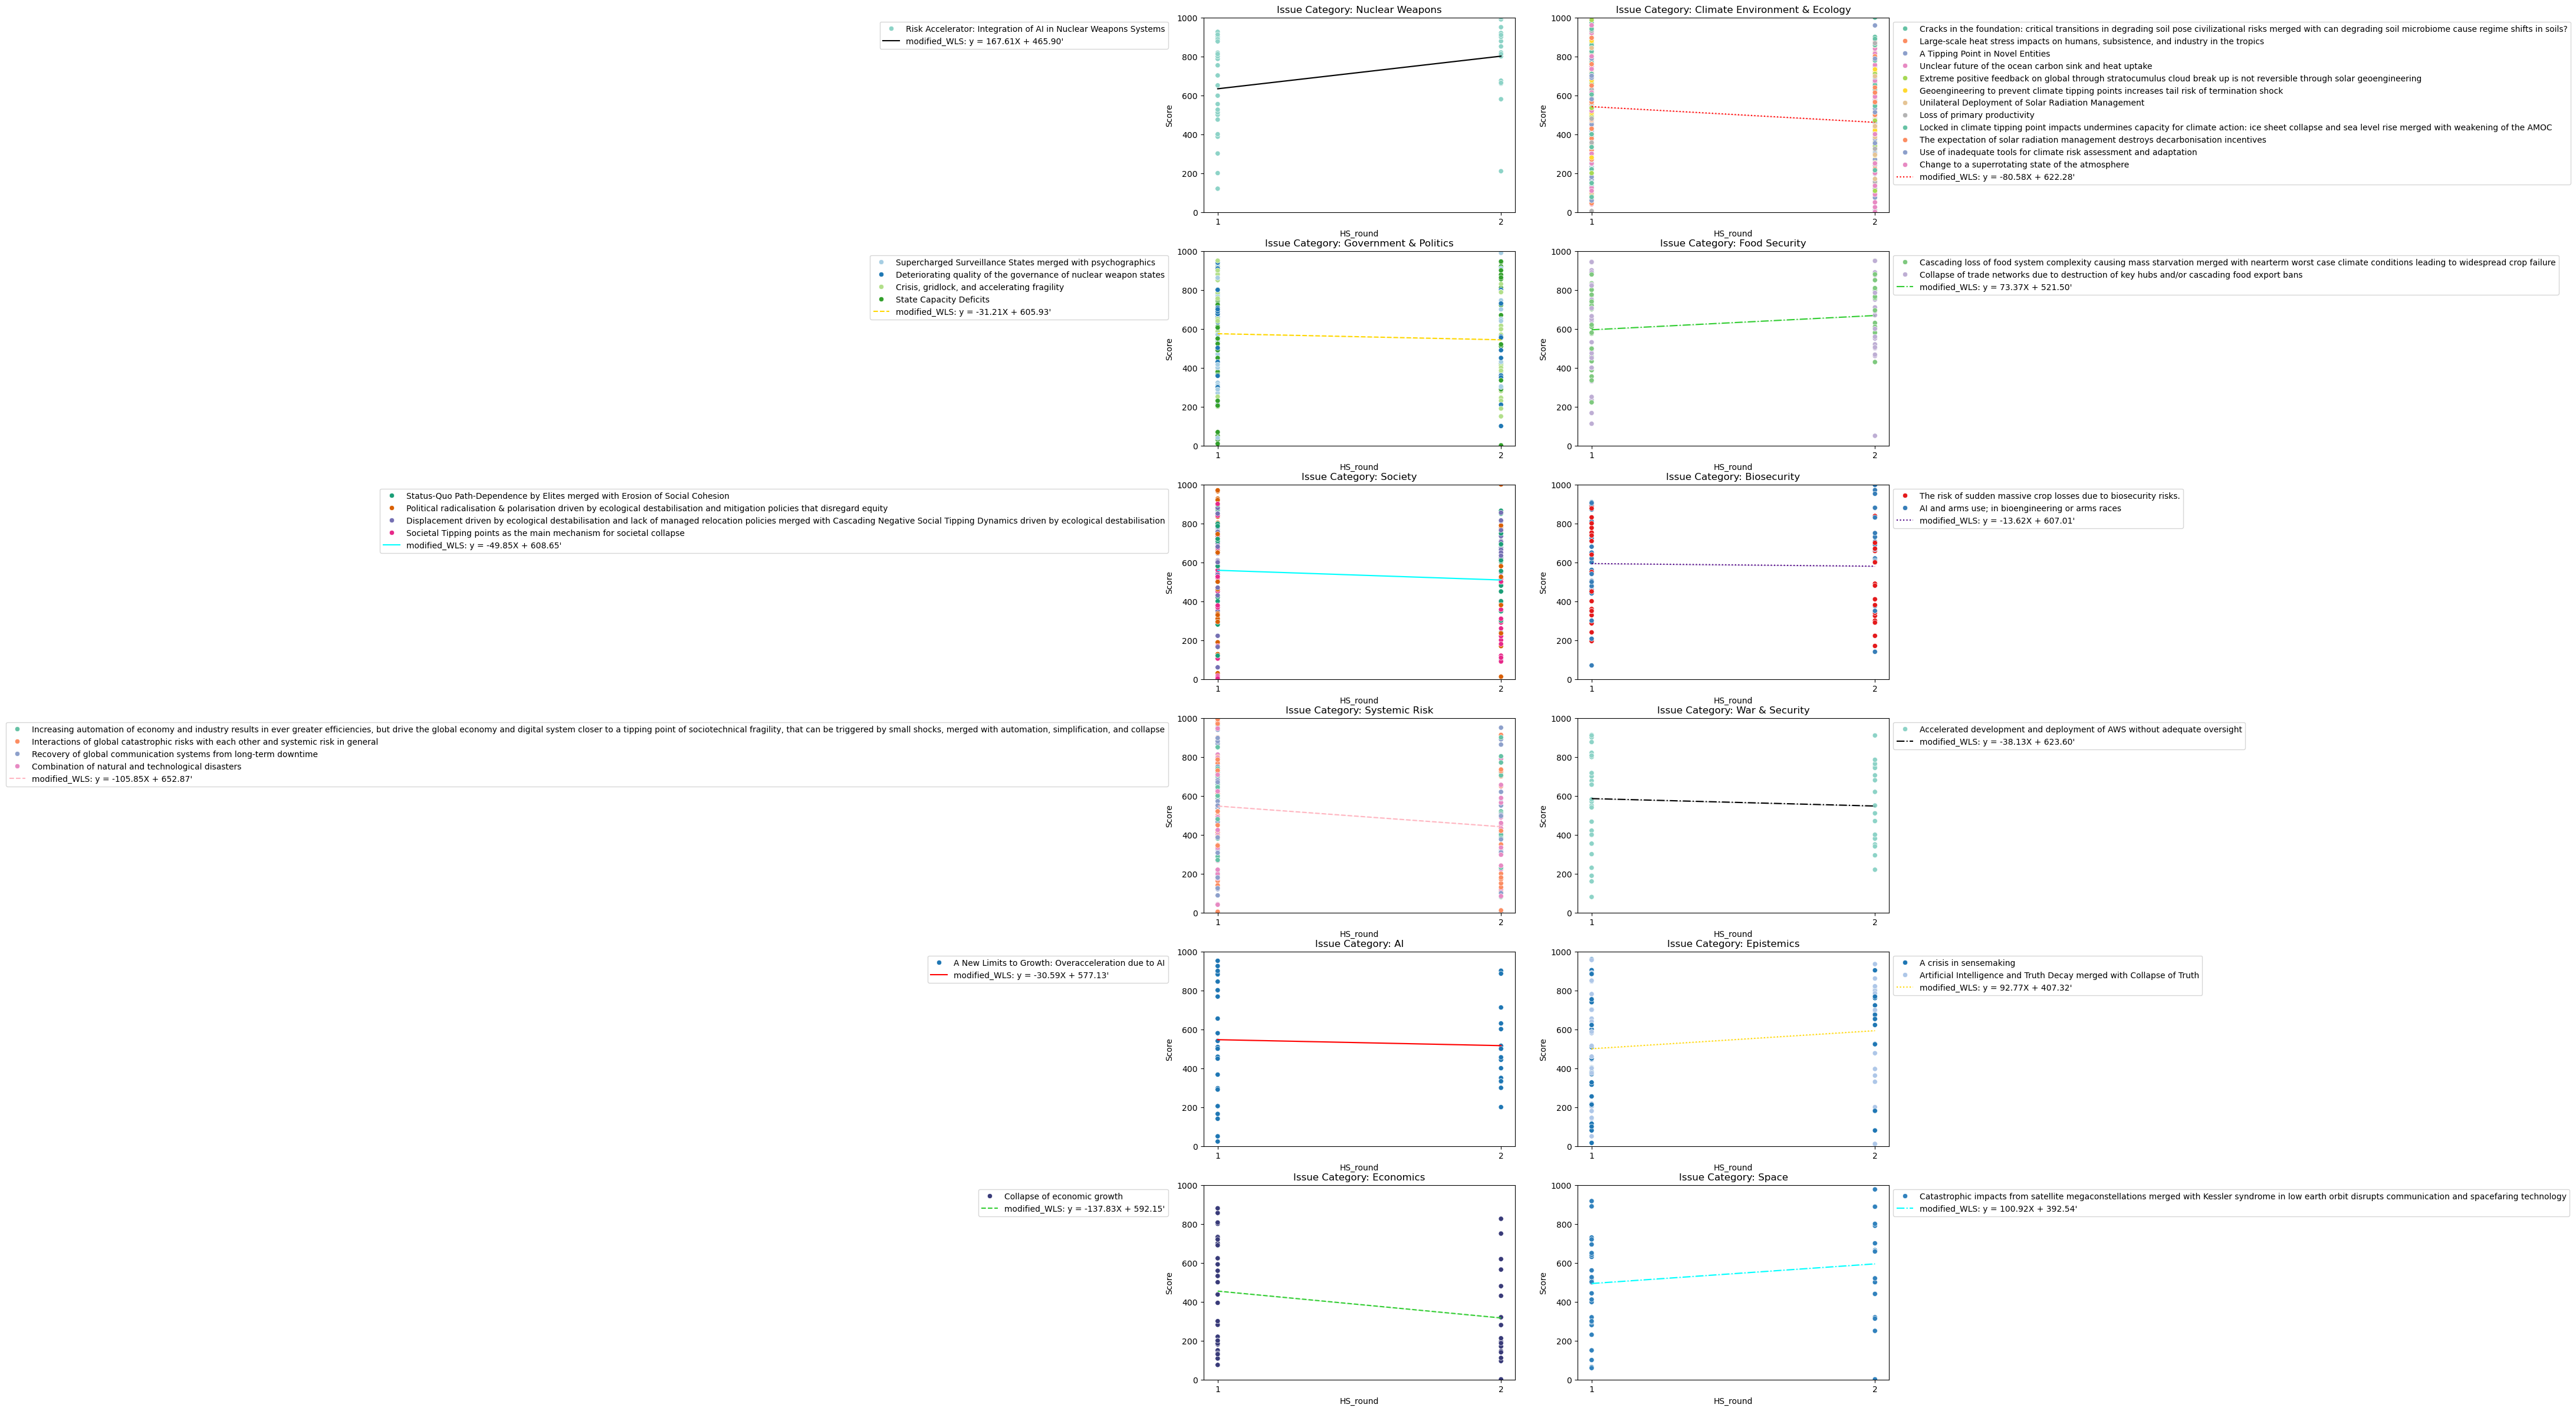

In [5]:
fig, ax = plt.subplots(6, 2, figsize=(15, 30))

axes = ax.flatten()

r1_exp = []
r2_exp = []


for idx, cat in enumerate(justScore_Ldf['Issue_cat'].unique()):
    palette_ls = ['Set3', 'Set2', 'Paired', 'Accent', 'Dark2', 'Set1',
                  'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
    linestyle_ls = ['solid', 'dotted', 'dashed', 'dashdot', 'solid',
                    'dotted', 'dashed', 'dashdot', 'solid', 'dotted',
                    'dashed', 'dashdot']
    colour_ls = ['black', 'red', 'gold', 'limegreen', 'cyan', 'indigo',
                 'lightpink', 'black', 'red', 'gold', 'limegreen', 'cyan']

    justScore_cat = justScore_Ldf[justScore_Ldf['Issue_cat'] == cat]

    # Inverse WLS that uses variance as weights
    y = justScore_cat['Score']
    x = justScore_cat['HS_round']
    X_sm = sm.add_constant(x)
    variance = justScore_cat.groupby('HS_round')['Score'].var()
    in_wt = justScore_cat['HS_round'].map(variance)

    # Create model, fit, and print results
    inv_WLS = sm.WLS(y, X_sm, weights = in_wt)
    res_inv = inv_WLS.fit()
    inv_ypred = res_inv.predict()
    print("\nModified WLS results")
    print(res_inv.summary())

    # Fill DataFrame
    r1_exp.append(inv_ypred[0])
    r2_exp.append(inv_ypred[-1])
    
    splot = sns.scatterplot(justScore_cat, x='HS_round', y='Score',
                            hue='Issue', ax=axes[idx], palette=palette_ls[idx])
    WLSplot = sns.lineplot(justScore_cat, x='HS_round', y=inv_ypred,
                           ax=axes[idx], linestyle=linestyle_ls[idx], color=colour_ls[idx],
                           label=f"modified_WLS: y = {res_inv.params[1]:.2f}X + {res_inv.params[0]:.2f}'")

    axes[idx].set_title(f"Issue Category: {cat}")
    axes[idx].set_xticks([1, 2])
    axes[idx].set_ylim(1-1, 1000)

    if idx % 2 == 0:
        # Left side subplots
        axes[idx].legend(bbox_to_anchor = (-0.1, 1), ncol=1)
    else:
        # Right side subplots
        axes[idx].legend(bbox_to_anchor=(1, 1), ncol=1)

plt.tight_layout()
plt.savefig(f"{fig_output}/WLSissueCat_subplots.png")
plt.show()

# DataFrame to collect inv_WLS ypred expected values
WLS_expDF = pd.DataFrame({
    "Issue_cat": justScore_Ldf["Issue_cat"].unique(),
    "round_1": r1_exp,
    "round_2": r2_exp
})

In [6]:
WLS_expDF_L = pd.melt(WLS_expDF, id_vars="Issue_cat", value_vars=["round_1", "round_2"], var_name="HS_round", value_name="Expected_Score")

WLS_expDF_L

,Issue_cat,HS_round,Expected_Score
0,Nuclear Weapons,round_1,633.503571
1,Climate Environment & Ecology,round_1,541.704762
2,Government & Politics,round_1,574.721429
3,Food Security,round_1,594.876786
4,Society,round_1,558.805357
5,Biosecurity,round_1,593.392857
6,Systemic Risk,round_1,547.017857
7,War & Security,round_1,585.464286
8,AI,round_1,546.535714
9,Epistemics,round_1,500.089286


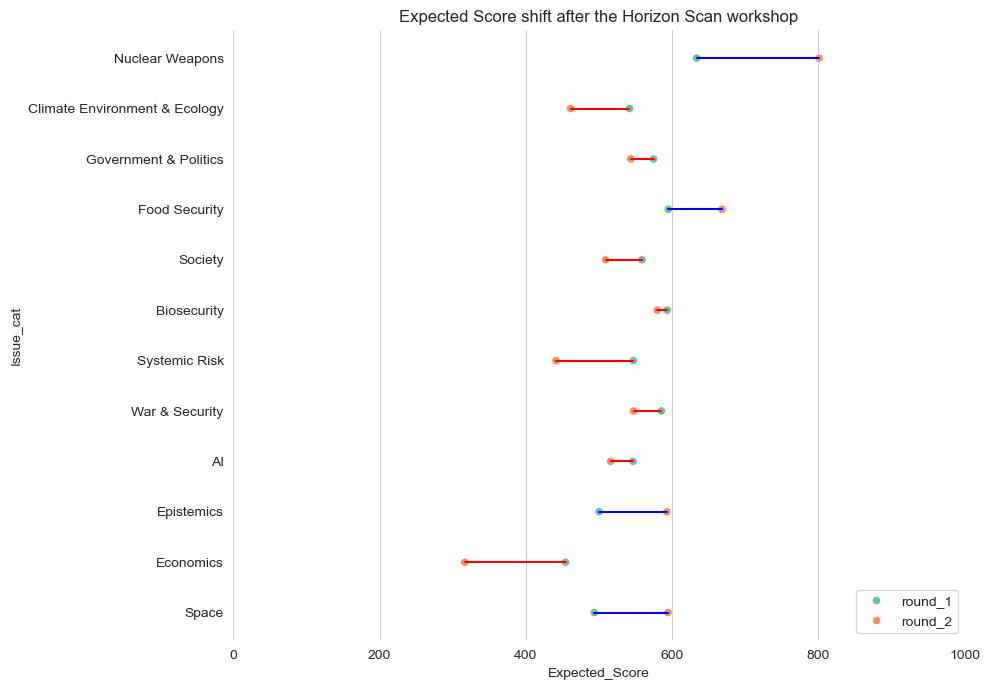

In [11]:
# Lollipop chart
sns.set_style('whitegrid', {'axes.facecolor': '1'})

fig, ax = plt.subplots(figsize = (10, 7))

lolli = sns.scatterplot(WLS_expDF_L, x="Expected_Score", y="Issue_cat",
                        hue="HS_round", palette="Set2")

for cat in WLS_expDF_L["Issue_cat"].unique():
    temp_df = WLS_expDF_L[WLS_expDF_L["Issue_cat"] == cat]

    r1_score = temp_df[temp_df["HS_round"] == "round_1"]["Expected_Score"].values[0]
    r2_score = temp_df[temp_df["HS_round"] == "round_2"]["Expected_Score"].values[0]

    if r2_score > r1_score:
        cane_col = "blue"
    else:
        cane_col = "red"        

    sns.lineplot(temp_df, x="Expected_Score", y="Issue_cat",
                 color=cane_col)

lolli.yaxis.grid(False)
lolli.legend(loc="lower right")
lolli.set_xlim(1-1, 1000)
sns.despine(left=True, bottom=True)
plt.title("Expected Score shift after the Horizon Scan workshop")

plt.tight_layout()
plt.savefig(f"{fig_output}/Deliberation_lolli.png")
plt.show()